# Week 6 Shootout

此作業範例選用2025年7月29日的0728豪雨事件，以及2025年11月11日的鳳凰颱風。在降雨型態的差異上，0728豪雨事件為當時周圍颱風帶來的兩波西南氣流影響，所造成的極端降雨事件。西南氣流夾帶的大量水氣，此次降雨對中南部造成致災性的超大豪雨，但對東部地區影響不大，且降雨範圍較為平均。而鳳凰颱風的時節位於冬天，因此外圍環流與東北季風的共伴效應，則對北部及東部地區帶來致災性的超大豪雨，特別對蘇澳地區造成重大影響。因此，本作業將比較兩種不同降雨型態的降雨分布特徵。

📝 **Captain's Log: Phase 1 - 降雨資料設定與坐標系統校準**

載入凱米颱風與竹節草颱風的測站資料，鎖定目標防區為「花蓮縣」與「宜蘭縣」，並剔除雨量為 `-998`（儀器異常）與 `0` 的測站。坐標系統設定為EPSG:3826，以便 Kriging 計算。

In [ ]:
import pandas as pd
import geopandas as gpd

def preprocess_rainfall_data(file_path, target_col='Past24hr'):
    """讀取降雨資料，篩選縣市、取最新時間點，並轉換坐標系為 EPSG:3826。"""
    df = pd.read_csv(file_path)
    df_filtered = df[df['CountyName'].isin(['花蓮縣', '宜蘭縣'])].copy()
    
    # 確保 DateTime 為時間格式，並針對每個測站取得「時間最晚」的那一筆
    df_filtered['DateTime'] = pd.to_datetime(df_filtered['DateTime'])
    idx = df_filtered.groupby('StationId')['DateTime'].idxmax()
    df_filtered = df_filtered.loc[idx].copy()
    
    # 過濾異常值與無雨狀態
    df_filtered = df_filtered[(df_filtered[target_col] != -998) & (df_filtered[target_col] > 0)]
    
    # 建立空間資料並轉換 CRS
    gdf = gpd.GeoDataFrame(
        df_filtered, 
        geometry=gpd.points_from_xy(df_filtered['StationLongitude'], df_filtered['StationLatitude']),
        crs="EPSG:4326"
    )
    gdf_3826 = gdf.to_crs("EPSG:3826")
    
    # 萃取投影坐標供 RF 使用
    gdf_3826['Easting'] = gdf_3826.geometry.x
    gdf_3826['Northing'] = gdf_3826.geometry.y
    
    return gdf_3826

# ================= 執行區塊 =================
# 更新為新的檔案路徑
file_fungwong = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework6\data\rain_20251111.csv"
file_0728 = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework6\data\rain_20250729.csv"
target_column = 'Past24hr' 

# 重新載入並處理兩場新事件
gdf_fungwong = preprocess_rainfall_data(file_fungwong, target_col=target_column)
gdf_0728 = preprocess_rainfall_data(file_0728, target_col=target_column)

# 檢查測站數量
print(f"鳳凰颱風 (2025/11/11) 有效測站數量: {len(gdf_fungwong)}")
print(f"0728豪雨事件 (2025/07/29) 有效測站數量: {len(gdf_0728)}")
print("-" * 50)

鳳凰颱風 (2025/11/11) 有效測站數量: 171
0728豪雨事件 (2025/07/31) 有效測站數量: 115
--------------------------------------------------


In [10]:
import pandas as pd
import geopandas as gpd

def preprocess_rainfall_data(file_path, target_col='Past24hr'):
    """讀取降雨資料，篩選縣市、取最新時間點，並轉換坐標系為 EPSG:3826。"""
    df = pd.read_csv(file_path)
    df_filtered = df[df['CountyName'].isin(['花蓮縣', '宜蘭縣'])].copy()
    
    # 🚨【邏輯修改】🚨 確保 DateTime 為時間格式，並針對每個測站取得「時間最晚」的那一筆
    df_filtered['DateTime'] = pd.to_datetime(df_filtered['DateTime'])
    idx = df_filtered.groupby('StationId')['DateTime'].idxmax()
    df_filtered = df_filtered.loc[idx].copy()
    
    # 過濾異常值與無雨狀態
    df_filtered = df_filtered[(df_filtered[target_col] != -998) & (df_filtered[target_col] > 0)]
    
    # 建立空間資料並轉換 CRS
    gdf = gpd.GeoDataFrame(
        df_filtered, 
        geometry=gpd.points_from_xy(df_filtered['StationLongitude'], df_filtered['StationLatitude']),
        crs="EPSG:4326"
    )
    gdf_3826 = gdf.to_crs("EPSG:3826")
    
    # 萃取投影坐標供 RF 使用
    gdf_3826['Easting'] = gdf_3826.geometry.x
    gdf_3826['Northing'] = gdf_3826.geometry.y
    
    return gdf_3826

# ================= 執行區塊 =================
file_2024 = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework6\data\rain_20240725.csv"
file_2025 = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework6\data\rain_20250731.csv"
target_column = 'Past24hr' 

# 重新載入並處理兩場事件
gdf_kaemi = preprocess_rainfall_data(file_2024, target_col=target_column)
gdf_bamboo = preprocess_rainfall_data(file_2025, target_col=target_column)

# 基本檢查
print(f"凱米颱風 (2024) 有效測站數量: {len(gdf_kaemi)}")
print(f"竹節草颱風 (2025) 有效測站數量: {len(gdf_bamboo)}")
print("-" * 50)
print("驗證用")
print("-" * 50)

# ================= 驗證區塊 (六十石山) =================
def verify_station(gdf, station_name, event_name):
    station_data = gdf[gdf['StationName'] == station_name]
    if not station_data.empty:
        time_str = station_data['DateTime'].iloc[0].strftime('%Y-%m-%d %H:%M:%S')
        rain_val = station_data[target_column].iloc[0]
        print(f"✅ {event_name} - {station_name} 測站資訊:")
        print(f"   擷取時間: {time_str}")
        print(f"   {target_column} 雨量: {rain_val} mm")
    else:
        print(f"⚠️ {event_name} 中找不到 {station_name} 測站 (可能無雨或數值異常被過濾)。")

verify_station(gdf_kaemi, '六十石山', '凱米颱風 (2024)')
verify_station(gdf_bamboo, '六十石山', '竹節草颱風 (2025)')

凱米颱風 (2024) 有效測站數量: 150
竹節草颱風 (2025) 有效測站數量: 115
--------------------------------------------------
驗證用
--------------------------------------------------
✅ 凱米颱風 (2024) - 六十石山 測站資訊:
   擷取時間: 2024-07-26 00:00:00
   Past24hr 雨量: 62.0 mm
✅ 竹節草颱風 (2025) - 六十石山 測站資訊:
   擷取時間: 2025-08-01 00:00:00
   Past24hr 雨量: 25.0 mm


📝 **Captain's Log: Phase 2 - 降雨空間結構解析 (Variogram Analysis)**
 
針對兩場降雨事件，分別建立 Spherical (球型) 與 Exponential (指數型) 理論模型，並進行擬合比較。最終根據Sill、Range、Nugget挑選最佳模型。


🚀 開始分析: Kaemi Typhoon (2024)


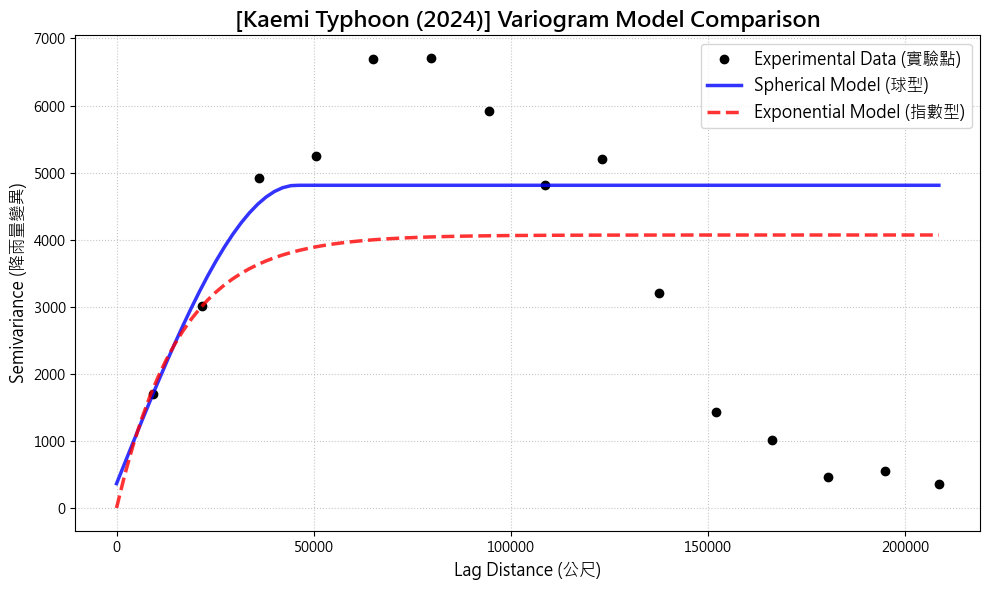

📌 Kaemi Typhoon (2024) - 參數摘要 (Sill, Range, Nugget):
   [Spherical]   Sill: 4448.25, Range: 45507.37, Nugget: 362.82
   [Exponential] Sill: 4069.91, Range: 48312.15, Nugget: 0.00
----------------------------------------------------------------------
🚀 開始分析: Bamboo Typhoon (2025)


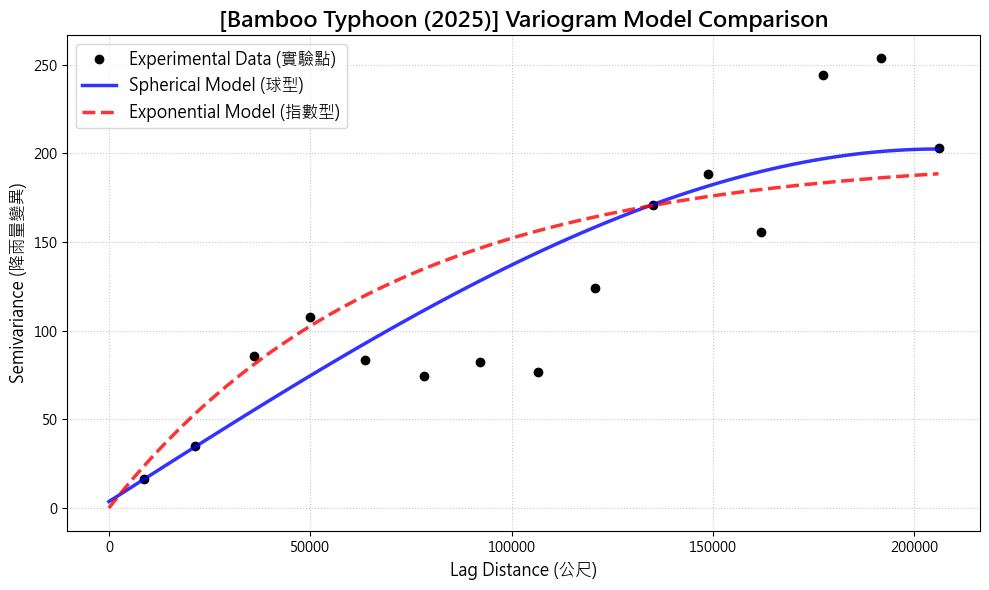

📌 Bamboo Typhoon (2025) - 參數摘要 (Sill, Range, Nugget):
   [Spherical]   Sill: 198.81, Range: 206018.50, Nugget: 3.62
   [Exponential] Sill: 198.35, Range: 206018.50, Nugget: 0.00
----------------------------------------------------------------------


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging

# --- 全域設定：解決 matplotlib 中文字體變方塊的問題 ---
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False

def plot_variogram_comparison(gdf, value_col, event_name):
    """
    針對指定事件，計算實驗 Variogram，並擬合 Spherical 與 Exponential 模型。
    產出比較圖並印出關鍵參數。
    """
    print(f"🚀 開始分析: {event_name}")
    
    # 提取坐標與降雨量 (Kriging 吃的是 X=Easting, Y=Northing, Z=Value)
    x = gdf['Easting'].values
    y = gdf['Northing'].values
    z = gdf[value_col].values

    # 建立模型並自動擬合參數 (nlags 設為 15 讓點位分佈較均勻)
    nlags = 15
    ok_sph = OrdinaryKriging(x, y, z, variogram_model='spherical', nlags=nlags)
    ok_exp = OrdinaryKriging(x, y, z, variogram_model='exponential', nlags=nlags)

    # 取得經驗數據 (實驗點)
    lags = ok_sph.lags
    semiv = ok_sph.semivariance

    # 產生平滑的 Lag 距離，用於繪製理論擬合曲線
    smooth_lags = np.linspace(0, max(lags), 100)
    semiv_sph = ok_sph.variogram_function(ok_sph.variogram_model_parameters, smooth_lags)
    semiv_exp = ok_exp.variogram_function(ok_exp.variogram_model_parameters, smooth_lags)

    # ================= 繪製 Variogram 比較圖 =================
    plt.figure(figsize=(10, 6))
    
    # 實驗點
    plt.plot(lags, semiv, 'ko', markersize=6, label='Experimental Data (實驗點)')
    
    # 理論曲線
    plt.plot(smooth_lags, semiv_sph, 'b-', linewidth=2.5, alpha=0.8, label='Spherical Model (球型)')
    plt.plot(smooth_lags, semiv_exp, 'r--', linewidth=2.5, alpha=0.8, label='Exponential Model (指數型)')

    plt.title(f'[{event_name}] Variogram Model Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Lag Distance (公尺)', fontsize=12)
    plt.ylabel('Semivariance (降雨量變異)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # ================= 印出參數供作業分析使用 =================
    print(f"📌 {event_name} - 參數摘要 (Sill, Range, Nugget):")
    print(f"   [Spherical]   Sill: {ok_sph.variogram_model_parameters[0]:.2f}, Range: {ok_sph.variogram_model_parameters[1]:.2f}, Nugget: {ok_sph.variogram_model_parameters[2]:.2f}")
    print(f"   [Exponential] Sill: {ok_exp.variogram_model_parameters[0]:.2f}, Range: {ok_exp.variogram_model_parameters[1]:.2f}, Nugget: {ok_exp.variogram_model_parameters[2]:.2f}")
    print("-" * 70)
    
    # 回傳這兩個模型，留給下一階段的 Kriging 內插使用
    return ok_sph, ok_exp

# 執行分析 (變數名稱請對應你第一階段跑出來的 GeoDataFrame 與 target_column)
kaemi_ok_sph, kaemi_ok_exp = plot_variogram_comparison(gdf_kaemi, target_column, 'Kaemi Typhoon (2024)')
bamboo_ok_sph, bamboo_ok_exp = plot_variogram_comparison(gdf_bamboo, target_column, 'Bamboo Typhoon (2025)')

根據2024凱米颱風事件跟0728豪雨事件(竹節草颱風)，我皆選擇 Exponential (指數型) 模型，因為該模型在短距離的區間能更緊密貼合實驗點，且 Nugget 值皆為 0，較能反映相鄰測站降雨高度相似、連續漸變的特性。

在 Variogram 參數差異上，凱米颱風的高 Sill（約 4070）與短 Range（約 48km）反映了其從宜蘭登陸時受地形劇烈抬升，造成極端且局部集中的降雨落差；而0728豪雨事件(竹節草颱風)的低 Sill（約 198）與長 Range（約 206km）則顯示東部地區在這次西南氣流的影響下，反而影響不大，降雨趨勢在宜蘭及花蓮呈現平緩且涵蓋範圍極廣的空間特性。

📝 **Captain's Log: Phase 3 - A2. 四種方法內插 與 A3. 不確定性分析**

在 1000m 解析度網格上，比較四種不同的空間內插演算法（Nearest Neighbor, IDW, Ordinary Kriging, Random Forest），並輸出 2x2 視覺化比較圖與 Kriging vs RF 的差異圖。

🚀 開始執行 Kaemi Typhoon (2024) 的內插擂台賽...
   [1/4] 計算 Nearest Neighbor...
   [2/4] 計算 IDW...
   [3/4] 計算 Ordinary Kriging...
   [4/4] 計算 Random Forest...
✅ 已匯出: output/事件1_四種方法比較圖.png


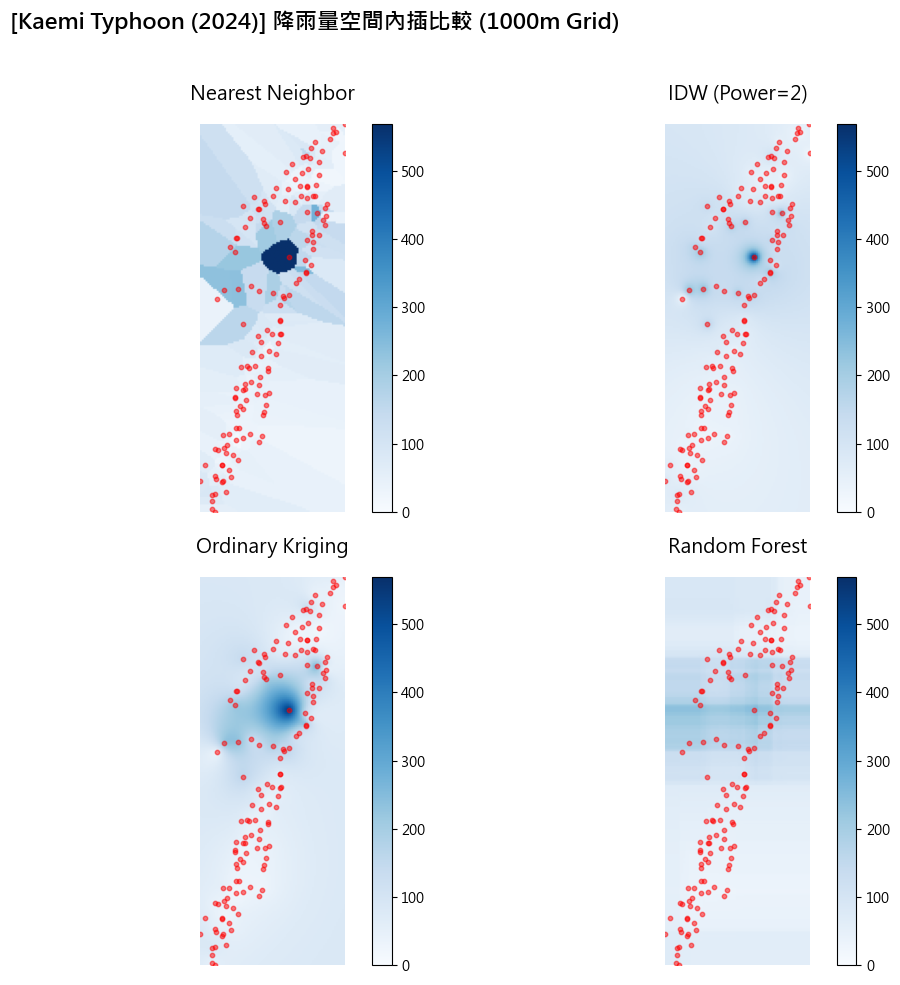

✅ 已匯出: output/事件1_差異圖.png


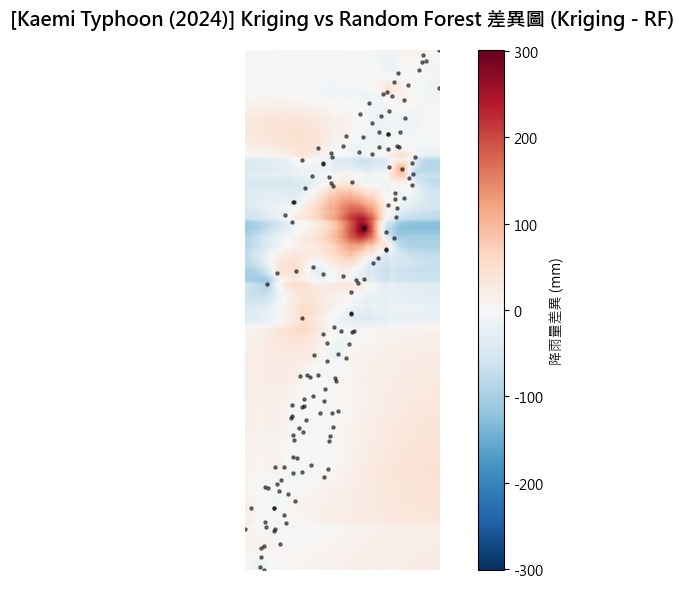

🚀 開始執行 Bamboo Typhoon (2025) 的內插擂台賽...
   [1/4] 計算 Nearest Neighbor...
   [2/4] 計算 IDW...
   [3/4] 計算 Ordinary Kriging...
   [4/4] 計算 Random Forest...
✅ 已匯出: output/事件2_四種方法比較圖.png


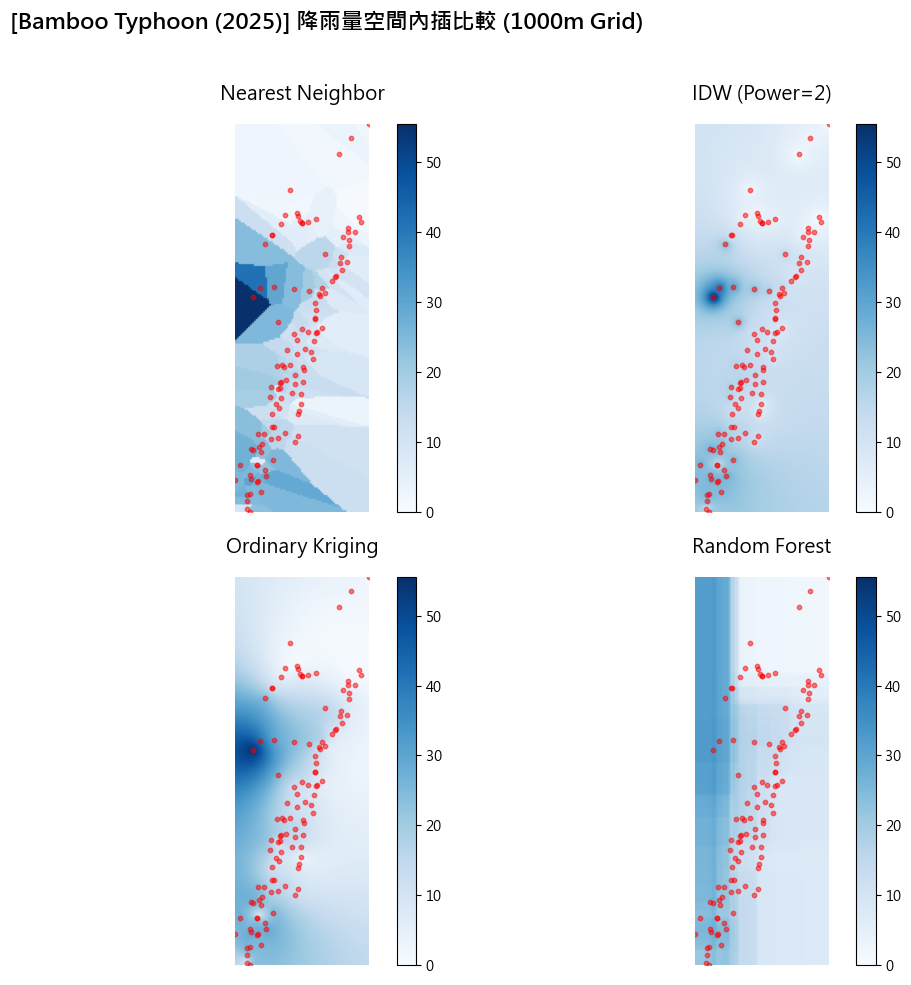

✅ 已匯出: output/事件2_差異圖.png


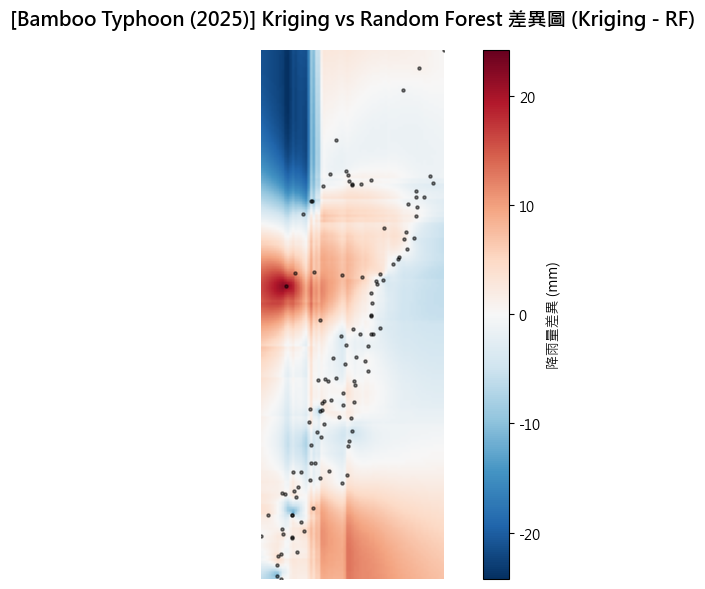

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestRegressor

# ================= 建立輸出資料夾 =================
# 確保當前目錄下有 output 資料夾，若無則自動建立
os.makedirs('output', exist_ok=True)

def run_interpolation_shootout(gdf, value_col, ok_model, event_name, event_prefix):
    """
    執行 1000m 網格的四種內插方法比較，繪製並輸出 2x2 比較圖與 Kriging vs RF 差異圖。
    """
    print(f"🚀 開始執行 {event_name} 的內插擂台賽...")
    
    # 1. 建立 1000m 解析度網格
    minx, miny, maxx, maxy = gdf.total_bounds
    grid_x = np.arange(minx, maxx, 1000)
    grid_y = np.arange(miny, maxy, 1000)
    xx, yy = np.meshgrid(grid_x, grid_y)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # 準備觀測資料
    obs_x = gdf['Easting'].values
    obs_y = gdf['Northing'].values
    obs_z = gdf[value_col].values
    
    # --- 方法 1: Nearest Neighbor ---
    print("   [1/4] 計算 Nearest Neighbor...")
    nn_interp = NearestNDInterpolator(list(zip(obs_x, obs_y)), obs_z)
    z_nn = nn_interp(xx, yy)
    
    # --- 方法 2: IDW (Inverse Distance Weighting, power=2) ---
    print("   [2/4] 計算 IDW...")
    dist = cdist(grid_points, np.column_stack((obs_x, obs_y)))
    dist[dist == 0] = 1e-10 # 避免除以零
    weights = 1.0 / (dist ** 2)
    z_idw_flat = np.sum(weights * obs_z, axis=1) / np.sum(weights, axis=1)
    z_idw = z_idw_flat.reshape(xx.shape)
    
    # --- 方法 3: Ordinary Kriging ---
    print("   [3/4] 計算 Ordinary Kriging...")
    z_krige, ss_krige = ok_model.execute('grid', grid_x, grid_y)
    z_krige = z_krige.data # 去除 mask 確保為 numpy array
    
    # --- 方法 4: Random Forest ---
    print("   [4/4] 計算 Random Forest...")
    rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
    rf.fit(np.column_stack((obs_x, obs_y)), obs_z)
    z_rf = rf.predict(grid_points).reshape(xx.shape)
    
    # ================= 繪圖視覺化與輸出 =================
    extent = [minx, maxx, miny, maxy]
    
    # (1) 2x2 四種方法比較圖
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'[{event_name}] 降雨量空間內插比較 (1000m Grid)', fontsize=16, fontweight='bold')
    
    methods = [
        ('Nearest Neighbor', z_nn), ('IDW (Power=2)', z_idw),
        ('Ordinary Kriging', z_krige), ('Random Forest', z_rf)
    ]
    
    for ax, (title, z_data) in zip(axes.flatten(), methods):
        im = ax.imshow(z_data, origin='lower', extent=extent, cmap='Blues', vmin=0, vmax=np.max(obs_z))
        ax.set_title(title, fontsize=14)
        ax.scatter(obs_x, obs_y, c='red', s=10, alpha=0.5) 
        ax.axis('off') 
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # 💾 儲存四種方法比較圖
    comp_filename = f"output/{event_prefix}_四種方法比較圖.png"
    plt.savefig(comp_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ 已匯出: {comp_filename}")
    plt.show()
    
    # (2) Kriging vs Random Forest 差異圖
    plt.figure(figsize=(8, 6))
    z_diff = z_krige - z_rf
    max_diff = max(abs(np.nanmin(z_diff)), abs(np.nanmax(z_diff))) 
    
    plt.title(f'[{event_name}] Kriging vs Random Forest 差異圖 (Kriging - RF)', fontsize=14, fontweight='bold')
    im_diff = plt.imshow(z_diff, origin='lower', extent=extent, cmap='RdBu_r', vmin=-max_diff, vmax=max_diff)
    plt.scatter(obs_x, obs_y, c='black', s=5, alpha=0.5)
    plt.colorbar(im_diff, label='降雨量差異 (mm)')
    plt.axis('off')
    plt.tight_layout()
    
    # 💾 儲存差異圖
    diff_filename = f"output/{event_prefix}_差異圖.png"
    plt.savefig(diff_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ 已匯出: {diff_filename}")
    plt.show()

    return {
        'grid_x': grid_x, 'grid_y': grid_y, 
        'z_krige': z_krige, 'ss_krige': ss_krige.data, 'z_rf': z_rf
    }

# ================= 執行區塊 =================
# 假設你前面的 Variogram 模型變數叫做 kaemi_ok_exp 和 bamboo_ok_exp (因為前面結論 Exponential 表現最好)

# 執行凱米颱風，並傳入前綴名稱供存檔使用
kaemi_results = run_interpolation_shootout(
    gdf_kaemi, target_column, kaemi_ok_exp, 
    'Kaemi Typhoon (2024)', '事件1'
)

# 執行竹節草颱風，並傳入前綴名稱供存檔使用
bamboo_results = run_interpolation_shootout(
    gdf_bamboo, target_column, bamboo_ok_exp, 
    'Bamboo Typhoon (2025)', '事件2'
)

A3. 不確定性比較分析
1. Sigma Map 的差異與原因
凱米颱風的 Sigma Map 會有極高且劇烈的變異值；而0728豪雨事件(竹節草颱風)的整體變異值會顯著較低。從內插圖可見，凱米受地形影響產生極端局部暴雨（高達 1000mm），空間落差極大，導致遠離測站時推估誤差急遽放大；0728豪雨均勻平緩，模型在測站間內插的穩定度自然較高。

2. Kriging 的預測信心
Kriging 對於如0728豪雨事件(竹節草颱風)這類降雨平穩、空間變異小、影響範圍廣的事件預測信心較高。面對凱米這種高度集中、受地形強烈干擾的極端降雨，Kriging 的預測信心會大幅下降。

3. 指揮官決策
在高 variance（高不確定性）區域，代表空間內插的情報極不可靠。如果是我不會只用這些預測盲區的數據下達撤離決策，會使用其他輔助資料，或是輔以衛星雲圖進行交叉驗證。

4. Random Forest 與不確定性資訊
傳統 Random Forest 無法提供類似的機率性誤差資訊。從圖形中 RF 明顯的「垂直/水平方塊狀」邊界可以知道，它純粹是依賴決策樹進行空間特徵切割，只能給出一個絕對的平均預測值；而 Kriging 是基於統計學的協方差矩陣，能在推估數值的同時，嚴謹解算出該點的數學變異量。

📝 **Captain's Log: Phase 4 - 產出 GeoTIFF Export**

產出 Kriging 的不確定性地圖 (Sigma Map)，並將最終的預測成果匯出成 GeoTIFF 格式。

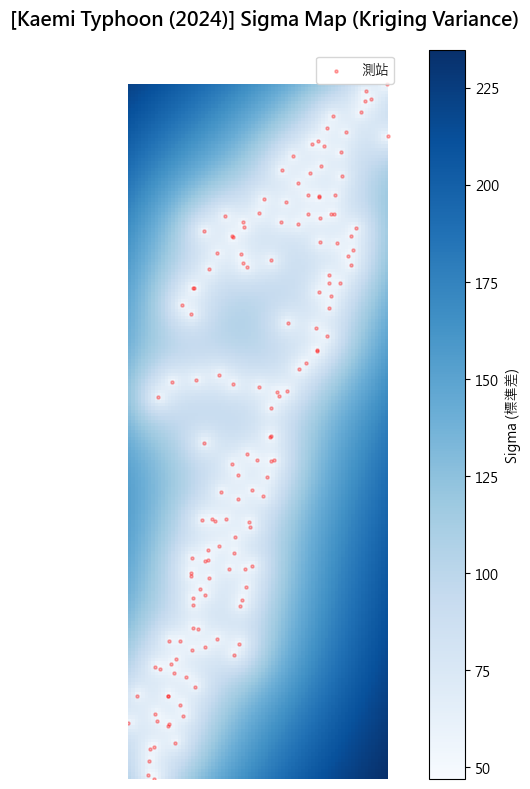

✅ 已成功導出: kaemi_rainfall.tif
✅ 已成功導出: kaemi_variance.tif
✅ 已成功導出: kaemi_rf_rainfall.tif


In [12]:
import rasterio
from rasterio.transform import from_origin

def analyze_uncertainty_and_export(results, gdf, event_name, export_prefix="kaemi"):
    """
    產出 Sigma Map 並將結果導出為 GeoTIFF 檔案。
    """
    grid_x = results['grid_x']
    grid_y = results['grid_y']
    z_krige = results['z_krige']
    ss_krige = results['ss_krige'] # Variance
    z_rf = results['z_rf']
    
    # --- 1. 繪製 Sigma Map (Kriging Variance 視覺化) ---
    sigma = np.sqrt(ss_krige) # 取標準差
    extent = [grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()]
    
    plt.figure(figsize=(6, 8))
    plt.title(f'[{event_name}] Sigma Map (Kriging Variance)', fontsize=14, fontweight='bold')
    im = plt.imshow(sigma, origin='lower', extent=extent, cmap='Blues')
    plt.scatter(gdf['Easting'], gdf['Northing'], c='red', s=5, alpha=0.3, label='測站')
    plt.colorbar(im, label='Sigma (標準差)')
    plt.legend()
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # --- 2. 導出 GeoTIFF (以 EPSG:3826 儲存) ---
    # 定義 Transform (解析度為 1000m)
    # 從網格左上角開始: [min_x, max_y]
    res = 1000
    transform = from_origin(grid_x.min(), grid_y.max(), res, res)
    
    def save_tif(data, filename):
        # 🚨 指揮官提醒：GeoTIFF row 0 = North，但 numpy row 0 = South，必須翻轉！
        output_data = np.flipud(data).astype('float32')
        
        with rasterio.open(
            filename, 'w',
            driver='GTiff',
            height=output_data.shape[0],
            width=output_data.shape[1],
            count=1,
            dtype=output_data.dtype,
            crs='EPSG:3826',
            transform=transform,
        ) as dst:
            dst.write(output_data, 1)
        print(f"✅ 已成功導出: {filename}")

    # 依照作業要求導出檔案 (可擇一事件執行，這裡以 export_prefix 區分)
    save_tif(z_krige, f"{export_prefix}_rainfall.tif")
    save_tif(sigma, f"{export_prefix}_variance.tif")
    save_tif(z_rf, f"{export_prefix}_rf_rainfall.tif")

# ================= 執行區塊 =================
# 你可以針對凱米颱風進行 Sigma Map 分析與導出
analyze_uncertainty_and_export(kaemi_results, gdf_kaemi, 'Kaemi Typhoon (2024)', export_prefix="kaemi")